In [3]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint


from project.networks.cbgt import ModelParams, ThalamusParams, BGParams
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display

# Change font of plots
use_latex_fonts()

This notebook is used to visualize the internal dynamics of the model. Two decision making tasks are run under default operating conditions, one for high and one for low coherence. Data from all ensembles are plotted

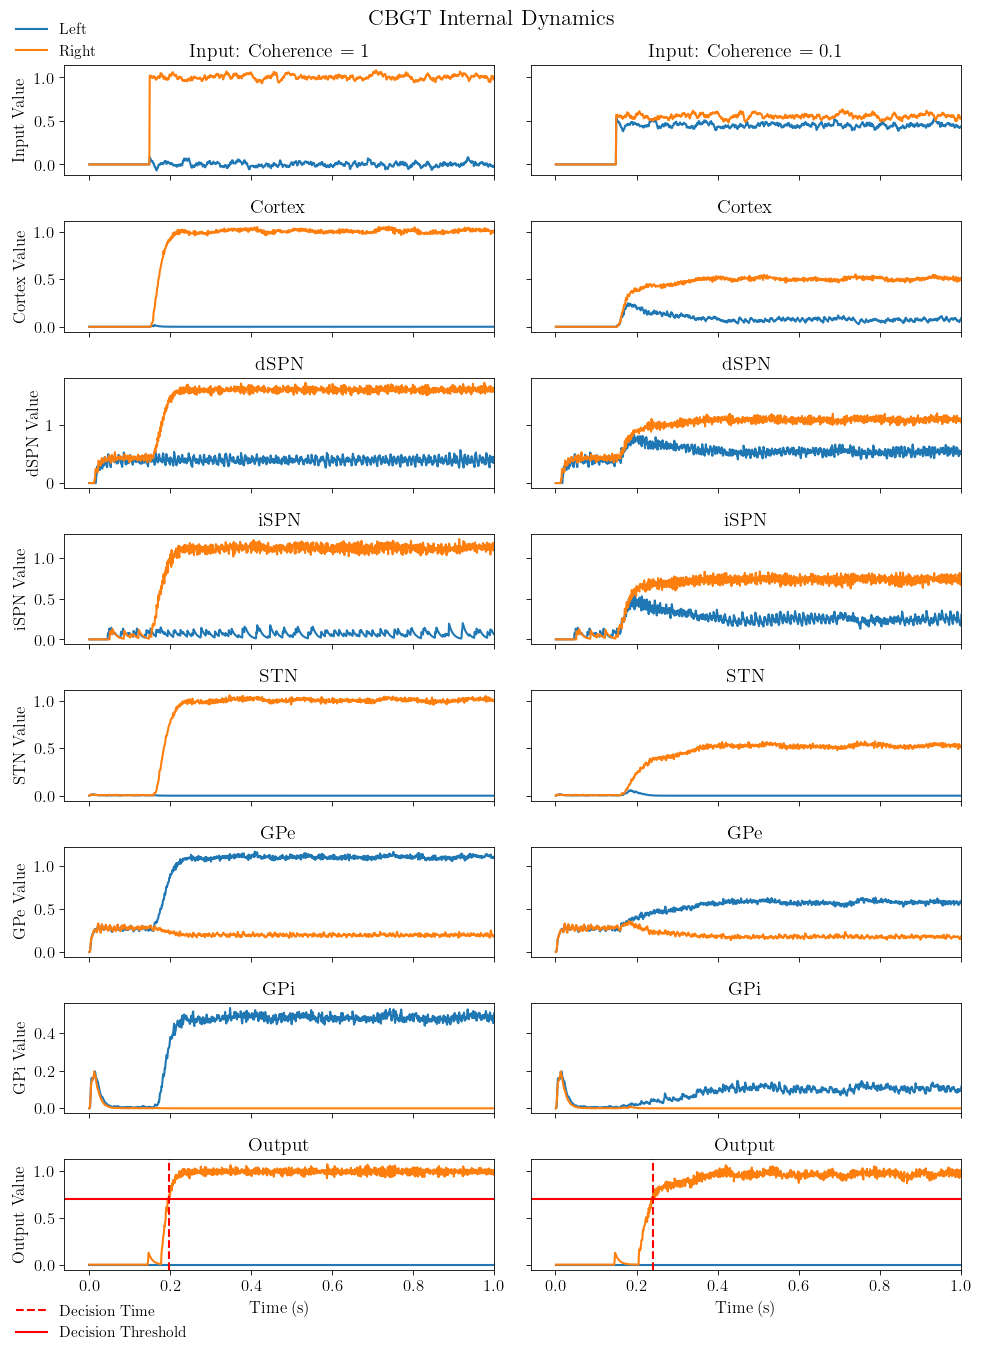

Saved: ..\figures\cbgt internals\cbgt internals.pdf
Saved: ..\figures\cbgt internals\cbgt internals.png


In [4]:
# ---- Parameters -----
task_seed = 2
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
task_params_high = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = 1,
    noise_std = 0.125
    )
task_params_low = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = 0.1,
    noise_std = 0.125
    )


# ---- Run decision-making task ----

# High Coherence
task_result = run_task(
    model_params = model_parameters,
    dots_params = task_params_high,
    trial_params = trial_params,
    return_probes = True,

)
# Low Coherence
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params_low,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = False
)

# ---- Get decision time for high noise condition ----
decision_time_high = task_result.decision_info['RT (ms)']/1000 + t_warmup
decision_time_low = task_result_low.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes = task_result.probes
probes_low = task_result_low.probes


# Time
time = probes['time']
time_low = probes_low['time']

# Input probes
input_probe = probes['input']
input_probe_low = probes_low['input']

# Cortex probes
cortex_probe = probes['cortex']
cortex_probe_low = probes_low['cortex']
# SPN probes
dSPN_probe = probes['dSPN']
iSPN_probe = probes['iSPN']
dSPN_probe_low = probes_low['dSPN']
iSPN_probe_low = probes_low['iSPN']

# Basal ganglia probes
STN_probe = probes['STN']
GPe_probe = probes['GPe']
GPi_probe = probes['GPi']
STN_probe_low = probes_low['STN']
GPe_probe_low = probes_low['GPe']
GPi_probe_low = probes_low['GPi']

# Output probes
output_probe_low = probes_low['output']
output_probe = probes['output']


# ---- Plot ----
fig, ax = plt.subplots(8, 2, figsize=(10, 14), sharex = True, sharey = 'row')

# High Coherence
Left, = ax[0,0].plot(time, input_probe[:,0], label = 'Left')
Right, = ax[0,0].plot(time, input_probe[:,1], label = 'Right')
ax[0,0].set_title('Input: Coherence $= 1$')

ax[1,0].plot(time, cortex_probe[:,0])
ax[1,0].plot(time, cortex_probe[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time, dSPN_probe[:,0])
ax[2,0].plot(time, dSPN_probe[:,1])
ax[2,0].set_title('dSPN')

ax[3,0].plot(time, iSPN_probe[:,0])
ax[3,0].plot(time, iSPN_probe[:,1])
ax[3,0].set_title('iSPN')

ax[4,0].plot(time, STN_probe[:,0])
ax[4,0].plot(time, STN_probe[:,1])
ax[4,0].set_title('STN')

ax[5,0].plot(time, GPe_probe[:,0])
ax[5,0].plot(time, GPe_probe[:,1])
ax[5,0].set_title('GPe')

ax[6,0].plot(time, GPi_probe[:,0])
ax[6,0].plot(time, GPi_probe[:,1])
ax[6,0].set_title('GPi')

ax[7,0].plot(time, output_probe[:,0])
ax[7,0].plot(time, output_probe[:,1])
ax[7,0].set_title('Output')

# Low Coherence
ax[0,1].plot(time_low, input_probe_low[:,0])
ax[0,1].plot(time_low, input_probe_low[:,1])
ax[0,1].set_title('Input: Coherence $= 0.1$')

ax[1,1].plot(time_low, cortex_probe_low[:,0])
ax[1,1].plot(time_low, cortex_probe_low[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_low, dSPN_probe_low[:,0])
ax[2,1].plot(time_low, dSPN_probe_low[:,1])
ax[2,1].set_title('dSPN')

ax[3,1].plot(time_low, iSPN_probe_low[:,0])
ax[3,1].plot(time_low, iSPN_probe_low[:,1])
ax[3,1].set_title('iSPN')

ax[4,1].plot(time_low, STN_probe_low[:,0])
ax[4,1].plot(time_low, STN_probe_low[:,1])
ax[4,1].set_title('STN')

ax[5,1].plot(time_low, GPe_probe_low[:,0])
ax[5,1].plot(time_low, GPe_probe_low[:,1])
ax[5,1].set_title('GPe')

ax[6,1].plot(time_low, GPi_probe_low[:,0])
ax[6,1].plot(time_low, GPi_probe_low[:,1])
ax[6,1].set_title('GPi')

ax[7,1].plot(time_low, output_probe_low[:,0])
ax[7,1].plot(time_low, output_probe_low[:,1])
ax[7,1].set_title('Output')
ax[7,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[7,0].set_xlabel('Time (s)')
ax[7,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('dSPN Value')
ax[3,0].set_ylabel('iSPN Value')
ax[4,0].set_ylabel('STN Value')
ax[5,0].set_ylabel('GPe Value')
ax[6,0].set_ylabel('GPi Value')
ax[7,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
ax[7,0].axhline(decision_threshold, color='r', linestyle='-')
ax[7,0].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')

decision_line = ax[7,1].axvline(decision_time_low, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[7,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.02),
    frameon=False
)

plt.suptitle('CBGT Internal Dynamics')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

save_plot(fig, 'cbgt internals', folder='../figures/cbgt internals', formats=('pdf', 'png'))